In [ ]:
## as part of first we have import all the libraries

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import datetime
from sklearn.preprocessing import MinMaxScaler

In [37]:
df= pd.read_csv('C:\\Users\\rajes\\Downloads\\sales.csv',parse_dates=['Date'],dtype={'Time':str,'State':str,'Group':str})


C:\Users\rajes\AppData\Local\Temp\ipykernel_58484\259643891.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df= pd.read_csv('C:\\Users\\rajes\\Downloads\\sales.csv',parse_dates=['Date'],dtype={'Time':str,'State':str,'Group':str})


In [92]:
df

,Date,Time,State,Group,Unit,Sales
0,2020-10-01,Morning,WA,Kids,8,20000
1,2020-10-01,Morning,WA,Men,8,20000
2,2020-10-01,Morning,WA,Women,4,10000
3,2020-10-01,Morning,WA,Seniors,15,37500
4,2020-10-01,Afternoon,WA,Kids,3,7500
...,...,...,...,...,...,...
7555,2020-12-30,Afternoon,TX,Seniors,14,35000
7556,2020-12-30,Evening,TX,Kids,15,37500
7557,2020-12-30,Evening,TX,Men,15,37500
7558,2020-12-30,Evening,TX,Women,11,27500


#To check null values

In [19]:
df.isna().sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

# Above code Shows number of NA values in dataset 

# Normalize Data for Analysis 

In [ ]:
normalize= MinMaxScaler()

In [49]:
df_dataonly= df[['Unit','Sales']]

In [50]:
normalize_data=normalize.fit_transform(df_dataonly)
normalize_data

array([[0.0952381 , 0.0952381 ],
       [0.0952381 , 0.0952381 ],
       [0.03174603, 0.03174603],
       ...,
       [0.20634921, 0.20634921],
       [0.14285714, 0.14285714],
       [0.17460317, 0.17460317]])

In [52]:
# to list down only normalized UNIT values
normalize_data[:,[0]]

array([[0.0952381 ],
       [0.0952381 ],
       [0.03174603],
       ...,
       [0.20634921],
       [0.14285714],
       [0.17460317]])

In [53]:
# to list down only normalized SALES values
normalize_data[:,[1]]

array([[0.0952381 ],
       [0.0952381 ],
       [0.03174603],
       ...,
       [0.20634921],
       [0.14285714],
       [0.17460317]])

Below code to Check the min and max values of each column. Min should be 0.0 
and max 1.0, for Unit and Sales column. 

In [55]:
print(normalize_data[:,[0]].min(),normalize_data[:,[0]].max())

0.0 0.9999999999999999


In [56]:
print(normalize_data[:,[1]].min(),normalize_data[:,[1]].max())

0.0 1.0


 Visualize Overall Trends 
• Plot the Date versus Unit and Date versus Sales line plot for the 
entire season. Note the values of Unit and Sales are summed up 
for each day.

In [58]:
dates =df['Date']
df_unit_and_sales = df.groupby(by=['Date']).agg({'Unit':'sum','Sales':'sum'})

df_unit_and_sales

,Unit,Sales
Date,,
2020-10-01,1488,3720000
2020-10-02,1486,3715000
2020-10-03,1556,3890000
2020-10-04,1488,3720000
2020-10-05,1545,3862500
...,...,...
2020-12-26,1886,4715000
2020-12-27,1855,4637500
2020-12-28,1838,4595000


In [59]:
df_oct=df_unit_and_sales.loc['2020-10-01':'2020-10-30']
df_nov=df_unit_and_sales.loc['2020-11-01':'2020-11-30']
df_dec=df_unit_and_sales.loc['2020-12-01':'2020-12-31']

<Axes: xlabel='Date', ylabel='Unit'>

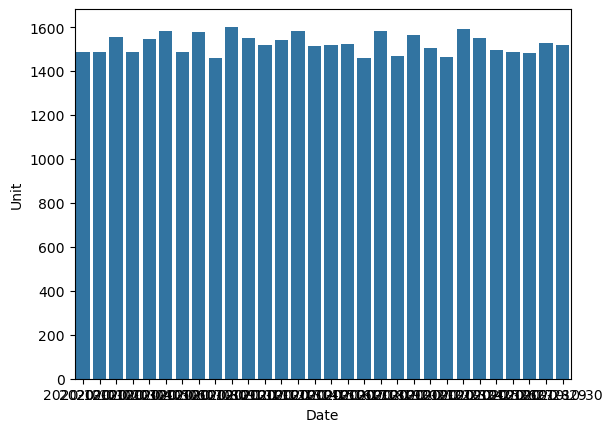

In [60]:
df_oct.index
sns.barplot(x=df_oct.index,y='Unit', data=df_oct)

<Axes: xlabel='Date', ylabel='Unit'>

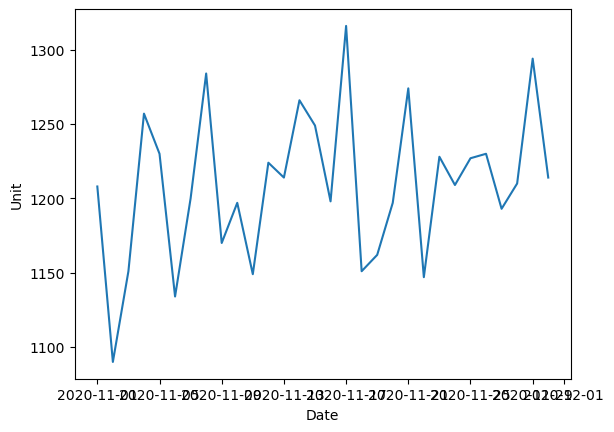

In [63]:

sns.lineplot(x=df_nov.index,y='Unit', data=df_nov)

<Axes: xlabel='Date', ylabel='Unit'>

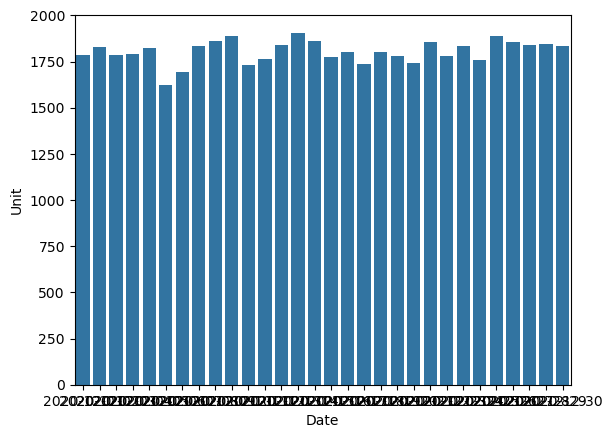

In [64]:
sns.barplot(x=df_dec.index,y='Unit', data=df_dec)

## Describe Data 
Describing the data will give you basic information such as count, 
mean, std (standard deviation), min, max and the quartiles. You will 
use the describe() command on the DataFrame to get it. All the 
values are for the entire three-month period. 
• For each of the three months, you can invoke describe() on df_oct, 
df_nov, and df_dec.

In [107]:
df.describe()
df_oct.describe()
df_nov.describe()
df_dec.describe()

,Unit,Sales
count,30.000000,3.000000e+01
mean,1804.400000,4.511000e+06
std,61.370329,1.534258e+05
min,1624.000000,4.060000e+06
25%,1775.750000,4.439375e+06
50%,1812.500000,4.531250e+06
75%,1842.750000,4.606875e+06
max,1906.000000,4.765000e+06


# Analyze Unit Data 
• Unit Analysis 
▪ You will use boxplots to visualize the distribution of 
units sold for each month. 


[Text(0.5, 1.0, 'december Units')]

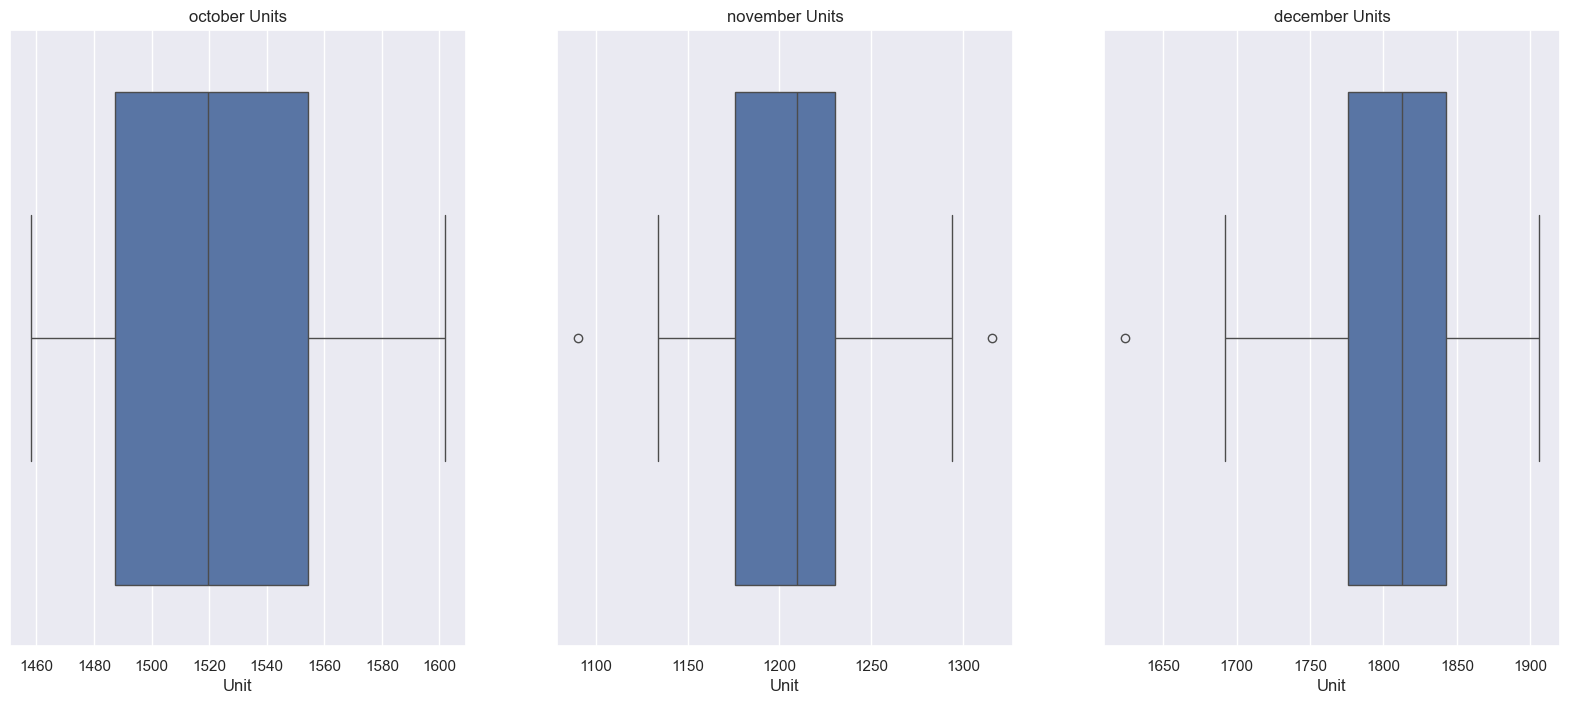

In [73]:
sns.set(rc={'figure.figsize':(20,8)})
fig, axes=plt.subplots(1,3)

bp_oct = sns.boxplot(x='Unit',data= df_oct,ax=axes [0])
bp_nov = sns.boxplot(x='Unit',data= df_nov,ax=axes [1])
bp_dec = sns.boxplot(x='Unit',data= df_dec,ax=axes [2])

bp_oct.set(title ='october Units')
bp_nov.set(title ='november Units')
bp_dec.set(title ='december Units')

In [ ]:
Sales Analysis 
▪ You will explore the distribution of sales revenue for 
each month.

[Text(0.5, 1.0, 'december Sales')]

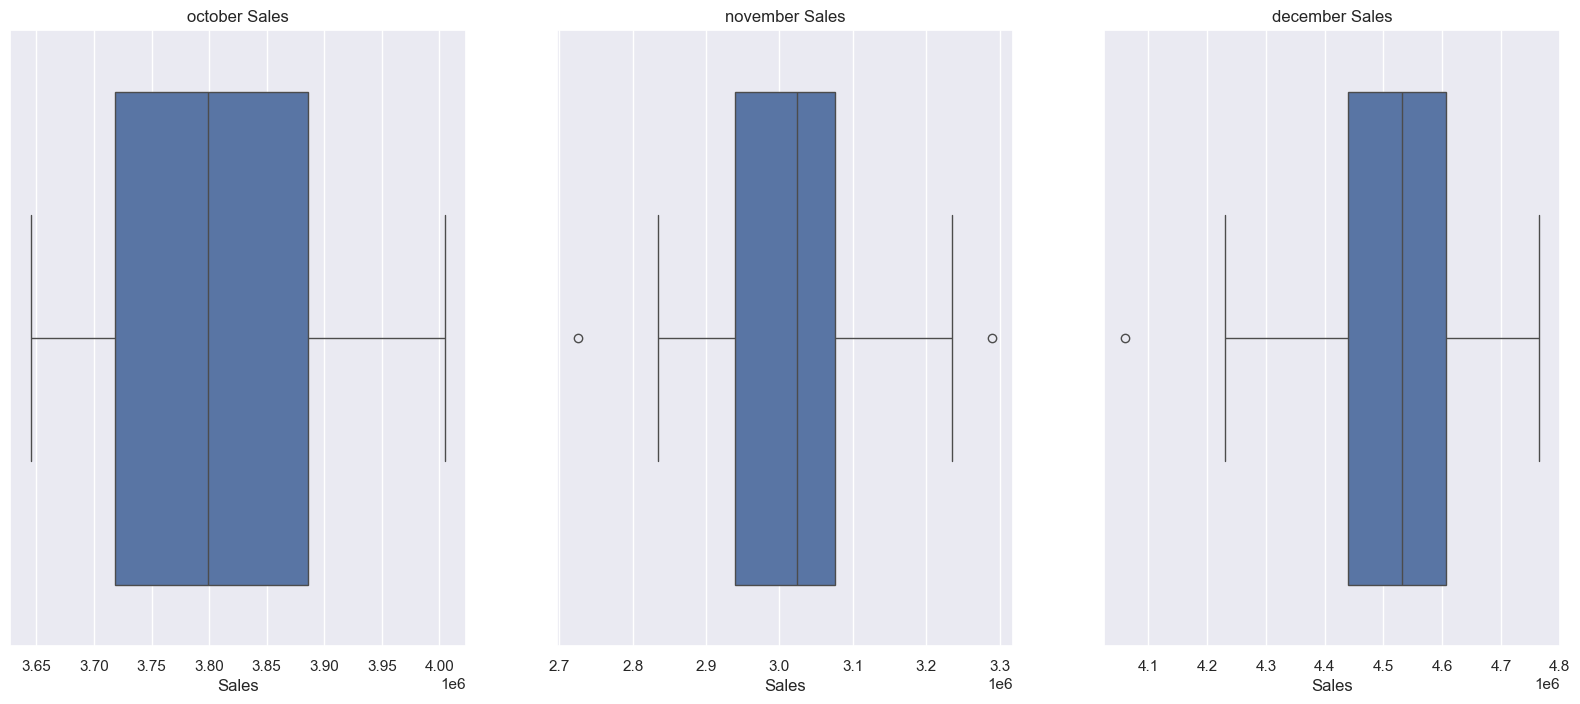

In [74]:
sns.set(rc={'figure.figsize':(20,8)})
fig, axes=plt.subplots(1,3)

bp_oct = sns.boxplot(x='Sales',data= df_oct,ax=axes [0])
bp_nov = sns.boxplot(x='Sales',data= df_nov,ax=axes [1])
bp_dec = sns.boxplot(x='Sales',data= df_dec,ax=axes [2])

bp_oct.set(title ='october Sales')
bp_nov.set(title ='november Sales')
bp_dec.set(title ='december Sales')

 Explore Monthly Plots and Analysis 
• Overall Unit and Sales figures 
• Units sold in October, November, and December 
• Sales numbers for October, November, and December 
• Consolidated 3-month sales plot 

In [110]:
oct_days =df_oct.index.day
oct_days.astype('str')

nov_days =df_nov.index.day
nov_days.astype('str')

dec_days =df_dec.index.day
dec_days.astype('str')


Index(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13',
       '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25',
       '26', '27', '28', '29', '30'],
      dtype='object', name='Date')

[Text(0.5, 1.0, 'december Units')]

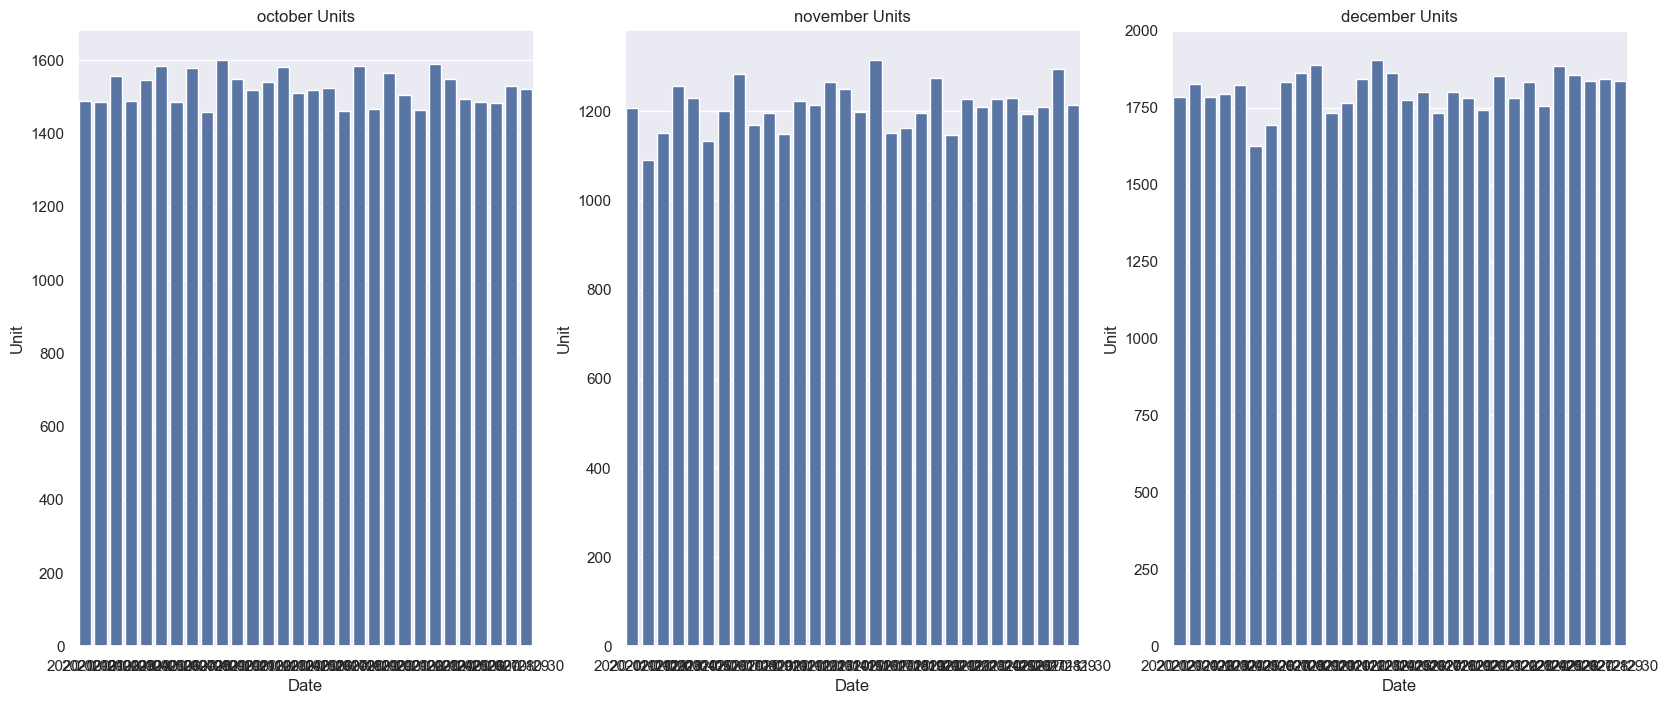

In [76]:
sns.set(rc={'figure.figsize':(20,8)})
fig, axes=plt.subplots(1,3)

bp_oct = sns.barplot(x=df_oct.index, y='Unit', data= df_oct,ax=axes [0])
bp_nov = sns.barplot(x=df_nov.index, y='Unit', data= df_nov,ax=axes [1])
bp_dec = sns.barplot(x=df_dec.index, y='Unit', data= df_dec,ax=axes [2])
bp_oct.set(title ='october Units')
bp_nov.set(title ='november Units')
bp_dec.set(title ='december Units')

[Text(0.5, 1.0, 'december Sales')]

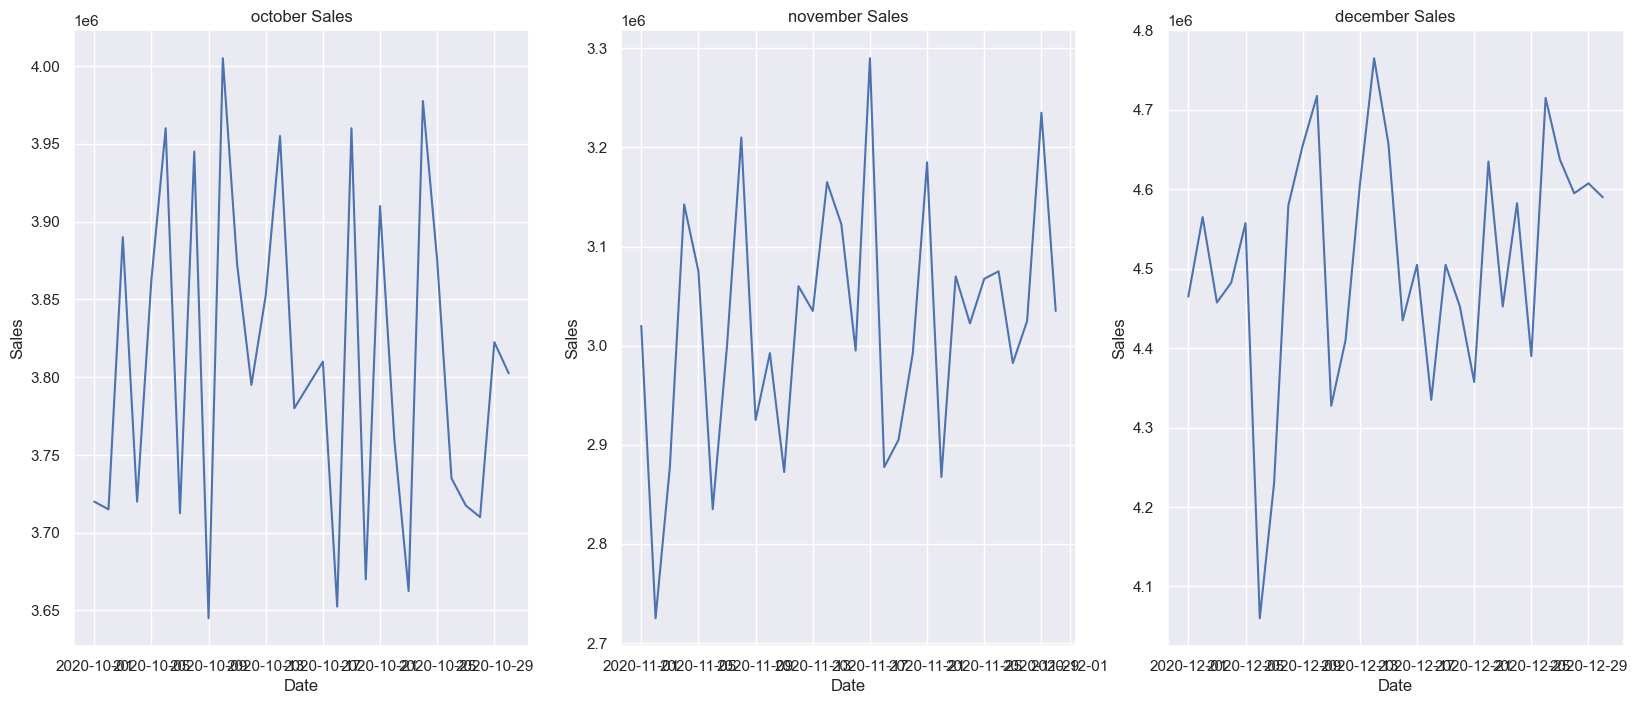

In [78]:
sns.set(rc={'figure.figsize':(20,8)})
fig, axes=plt.subplots(1,3)

lp_oct = sns.lineplot(x=df_oct.index, y='Sales', data= df_oct,ax=axes [0])
lp_nov = sns.lineplot(x=df_nov.index, y='Sales', data= df_nov,ax=axes [1])
lp_dec = sns.lineplot(x=df_dec.index, y='Sales', data= df_dec,ax=axes [2])
lp_oct.set(title ='october Sales')
lp_nov.set(title ='november Sales')
lp_dec.set(title ='december Sales')

Obtain a Comprehensive Snapshot 

[Text(0.5, 1.0, 'december Sales')]

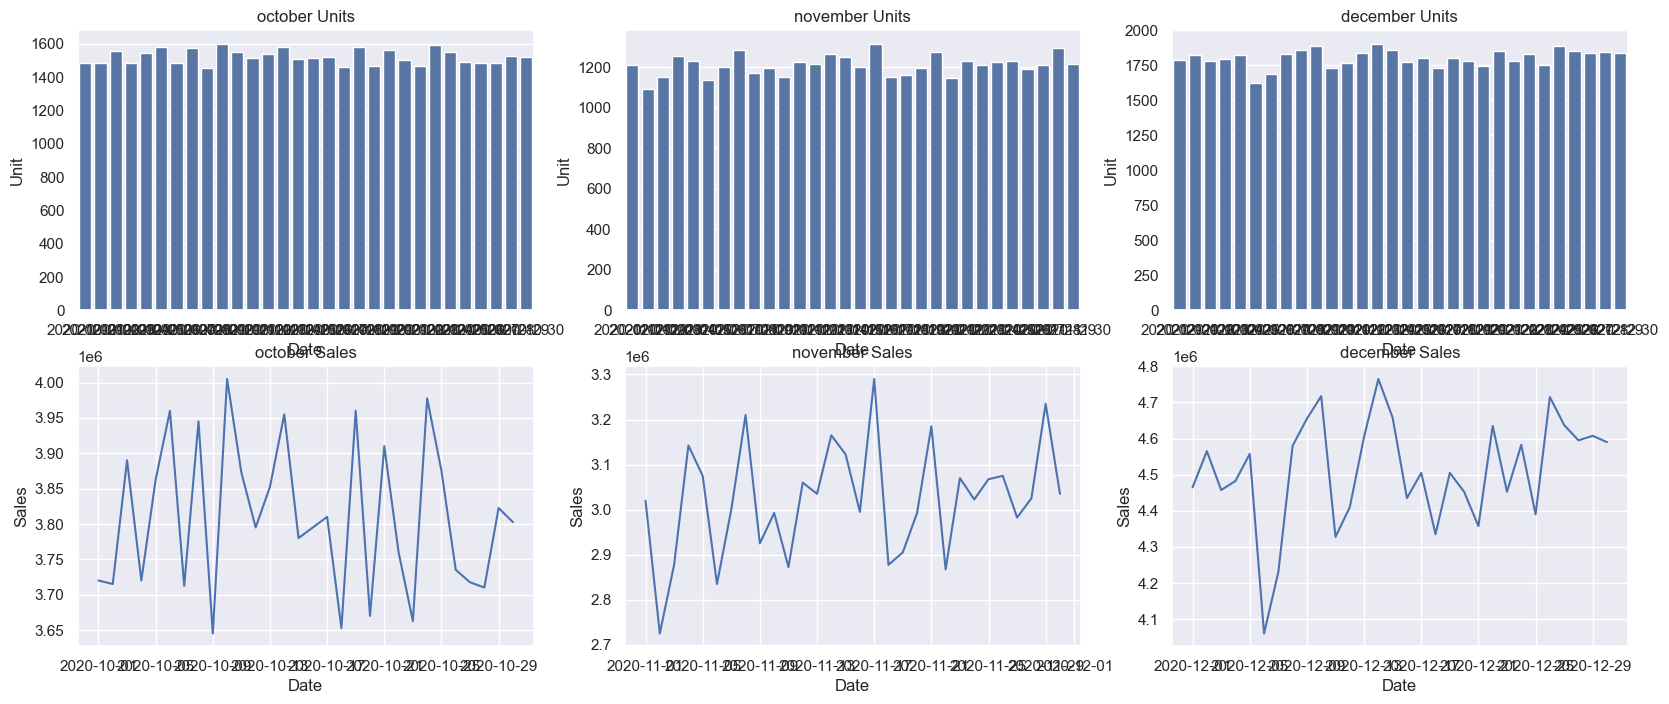

In [79]:
fig, axes=plt.subplots(2,3)

bp_oct = sns.barplot(x=df_oct.index, y='Unit', data= df_oct,ax=axes [0,0])
bp_nov = sns.barplot(x=df_nov.index, y='Unit', data= df_nov,ax=axes [0,1])
bp_dec = sns.barplot(x=df_dec.index, y='Unit', data= df_dec,ax=axes [0,2])
bp_oct.set(title ='october Units')
bp_nov.set(title ='november Units')
bp_dec.set(title ='december Units')

lp_oct = sns.lineplot(x=df_oct.index, y='Sales', data= df_oct,ax=axes [1,0])
lp_nov = sns.lineplot(x=df_nov.index, y='Sales', data= df_nov,ax=axes [1,1])
lp_dec = sns.lineplot(x=df_dec.index, y='Sales', data= df_dec,ax=axes [1,2])
lp_oct.set(title ='october Sales')
lp_nov.set(title ='november Sales')
lp_dec.set(title ='december Sales')

Analyze Statewise Sales in the United States 

In [86]:
state_pivot =pd.pivot_table(df,values=['Sales','Unit'],index ='State',aggfunc=['sum','mean'])
state_pivot

sum                 mean           
           Sales   Unit         Sales       Unit
State                                           
 WA     22152500   8861  20511.574074   8.204630
AZ      22580000   9032  20907.407407   8.362963
CA      33417500  13367  30942.129630  12.376852
FL      58857500  23543  54497.685185  21.799074
KY     105565000  42226  97745.370370  39.098148
NY      74970000  29988  69416.666667  27.766667
TX      22760000   9104  21074.074074   8.429630

 Conduct Groupwise Analysis 

In [88]:
group_pivot =pd.pivot_table(df,values=['Sales','Unit'],index ='Group',aggfunc=['sum','mean'])
group_pivot

sum                 mean           
            Sales   Unit         Sales       Unit
Group                                            
Kids     85072500  34029  45011.904762  18.004762
Men      85750000  34300  45370.370370  18.148148
Seniors  84037500  33615  44464.285714  17.785714
Women    85442500  34177  45207.671958  18.083069

In [89]:
time_pivot =pd.pivot_table(df,values=['Sales','Unit'],index ='Time',aggfunc=['sum','mean'])
time_pivot

sum                 mean           
               Sales   Unit         Sales       Unit
Time                                                
Afternoon  114007500  45603  45241.071429  18.096429
Evening    112087500  44835  44479.166667  17.791667
Morning    114207500  45683  45320.436508  18.128175

In [94]:
df_oct=df_unit_and_sales.loc['2020-10-01':'2020-10-30']

In [95]:
df_oct

,Unit,Sales
Date,,
2020-10-01,1488,3720000
2020-10-02,1486,3715000
2020-10-03,1556,3890000
2020-10-04,1488,3720000
2020-10-05,1545,3862500
2020-10-06,1584,3960000
2020-10-07,1485,3712500
2020-10-08,1578,3945000
2020-10-09,1458,3645000
